###**Proyecto final - Formula 1**

**Integrantes:**

Edwin Leal Guadalajara

Kevin Javier Perez Meza

Diego Alberto Rivera Galván

María Fernanda Sánchez Rentería

Fernanda Lizeth Zambrano Gudiño

**Materias:**

- Machine Learning e inferencia Bayesiana

- Matemáticas aplicadas a ciencia de datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [ ]:
# Scikit-Learn (para knn)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, roc_auc_score, ConfusionMatrixDisplay

# Scikit-Learn (para dtc)
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import KFold, cross_val_score

# Graphviz para visualizar el árbol
from graphviz import Source

##Análisis exploratorio

In [ ]:
#Extraer los datos

url = 'https://raw.githubusercontent.com/Goyoboss/proyecto_cugdlA/refs/heads/main/Data/df_limpio.csv'

df_limpio = pd.read_csv(url) #limpieza de datos en el notebook de estadistica
df_limpio.head()

,raceId,driverId,stop,seconds,driverRef,forename,nationality,position,clase_pos
0,841,1,2,46.426,hamilton,Lewis,British,2.0,1
1,841,4,3,72.165,alonso,Fernando,Spanish,4.0,0
2,841,13,3,72.437,massa,Felipe,Brazilian,7.0,0
3,841,16,2,49.849,sutil,Adrian,German,9.0,0
4,841,17,3,72.176,webber,Mark,Australian,5.0,0


In [ ]:
df_limpio.info() #Conocer el tipo de datos de cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2702 entries, 0 to 2701
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   raceId       2702 non-null   int64  
 1   driverId     2702 non-null   int64  
 2   stop         2702 non-null   int64  
 3   seconds      2702 non-null   float64
 4   driverRef    2702 non-null   object 
 5   forename     2702 non-null   object 
 6   nationality  2702 non-null   object 
 7   position     2702 non-null   float64
 8   clase_pos    2702 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 190.1+ KB


In [ ]:
print(f'---Distribución de la clase de posiciones---')
display(df_limpio['clase_pos'].value_counts()) #notamos que los datos están desbalanceados

---Distribución de la clase de posiciones---


,count
clase_pos,
0,1870
1,832


In [ ]:
#Quitamos raceId y driverId pues no aportan información para los modelos
df_ml = df_limpio.drop(['raceId', 'driverId', 'forename'], axis=1) #position se quita puesto que es redundante con clase_pos

print('--- Nuevo dataframe ---')
display(df_ml.head())

--- Nuevo dataframe ---


,stop,seconds,driverRef,nationality,position,clase_pos
0,2,46.426,hamilton,British,2.0,1
1,3,72.165,alonso,Spanish,4.0,0
2,3,72.437,massa,Brazilian,7.0,0
3,2,49.849,sutil,German,9.0,0
4,3,72.176,webber,Australian,5.0,0


In [ ]:
num_cols = df_ml.select_dtypes(include='number').columns #variables numéricas
df_ml[num_cols].groupby('clase_pos').mean() #se agrupan las variables numericas por la clase

'''
es la media de cada clase por posición, paradas en boxes y segundos en cada parada de boxes
'''

,stop,seconds,position
clase_pos,,,
0,1.995187,182.138747,6.985561
1,2.031250,186.455341,1.996394


In [ ]:
#tabla de contingencia

cat_cols = df_ml.select_dtypes(include='object').columns #variables categóricas

for col in cat_cols:
    display(pd.crosstab(df_ml[col], df_ml['clase_pos'], normalize='index')\
              .style.format("{:.1%}").set_caption(f"Distribución de la clase de posición según {col}"))

clase_pos,0,1
driverRef,,
albon,100.0%,0.0%
alonso,63.8%,36.2%
bearman,100.0%,0.0%
bottas,57.4%,42.6%
bruno_senna,100.0%,0.0%
buemi,100.0%,0.0%
button,80.0%,20.0%
ericsson,100.0%,0.0%
gasly,100.0%,0.0%


clase_pos,0,1
nationality,,
Australian,78.5%,21.5%
Belgian,100.0%,0.0%
Brazilian,100.0%,0.0%
British,59.1%,40.9%
Canadian,100.0%,0.0%
Chinese,100.0%,0.0%
Danish,97.9%,2.1%
Dutch,38.2%,61.8%
Finnish,62.8%,37.2%


In [ ]:
'''
el '0' indica cuantas veces han aparecido los datos en el dataframe, por ejemplo, el conductor con ID = 1,
quien es hamilton, indica que ha quedado 276 veces dentro de los primeros 10 lugares (se limito de esta manera)
'''
df_limpio.groupby(['nationality', 'driverId']).size().to_frame()

0
nationality driverId     
Australian  17         56
            817       137
            857        30
Belgian     838         1
Brazilian   13        101
            811         2
            831         7
British     1         276
            18         75
            814        20
            846       109
            847        67
            860         1
Canadian    840        42
Chinese     855         1
Danish      825        47
Dutch       830       178
Finnish     8         122
            822       176
French      154        49
            818         1
            839        52
            842        59
German      2           9
            3         106
            16          4
            20        177
            30         15
            807        74
Italian     841         1
Japanese    155         9
            852         8
Mexican     815       188
Monegasque  844       120
Russian     808        18
            826        29
Spanish     4         163
            832       139
Swedish     828         1
Swiss       67          2
Thai        848        26
Venezuelan  813         4

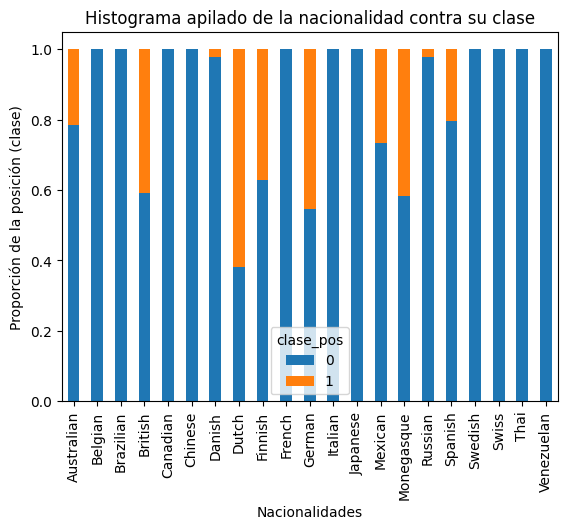

In [ ]:
table = pd.crosstab(df_ml.nationality, df_ml.clase_pos)
table.div(table.sum(1).astype(float), axis = 0).plot(kind = 'bar', stacked = True) #division por filas y que lo haga por columnas
# cada columna queda dividido por la suma de las filas
plt.title('Histograma apilado de la nacionalidad contra su clase')
plt.xlabel('Nacionalidades')
plt.ylabel('Proporción de la posición (clase)')
plt.show()

<Axes: xlabel='clase_pos', ylabel='stop'>

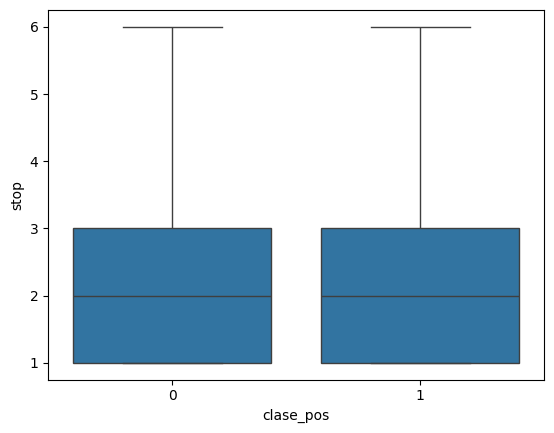

In [ ]:
sns.boxplot(x='clase_pos', y='stop', data=df_limpio)

#Construcción y evaluación de modelos predictivos

In [ ]:
X = df_limpio.drop(columns=['clase_pos', 'position']) #features
y = df_limpio['clase_pos'] #target

num_cols = X.select_dtypes(include=np.number).columns.tolist()
# Include 'category' dtype to ensure columns like 'clase' are captured
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
scaler = StandardScaler()
encoder = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_cols),
        ('cat', encoder, cat_cols)
    ]
    ,remainder='drop'
)

#aplicacion

X_processed = preprocessor.fit_transform(X)
print(X_processed)

[[-1.71599891 -1.18549032 -0.00648803 ...  0.          0.
   0.        ]
 [-1.71599891 -1.17805196  1.02472758 ...  0.          0.
   0.        ]
 [-1.71599891 -1.15573689  1.02472758 ...  0.          0.
   0.        ]
 ...
 [ 1.697827    0.9096471  -1.03770365 ...  0.          0.
   0.        ]
 [ 1.697827    0.91212655 -1.03770365 ...  0.          0.
   0.        ]
 [ 1.697827    0.93692107 -0.00648803 ...  0.          0.
   0.        ]]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [ ]:
#diccionario
keys= ['LR', 'DTC', 'RFC', 'SVC', 'KNN']
values = [LogisticRegression(max_iter=1000, penalty='l2'),
          DecisionTreeClassifier(max_depth=10, min_samples_split=30, min_samples_leaf=7),
          RandomForestClassifier(max_depth=10, min_samples_split=30, min_samples_leaf=7, n_estimators=30),
          SVC(C=0.1, kernel='rbf'),
          KNeighborsClassifier(n_neighbors=5)]
models=  dict(zip(keys, values))
models

{'LR': LogisticRegression(max_iter=1000),
 'DTC': DecisionTreeClassifier(max_depth=10, min_samples_leaf=7, min_samples_split=30),
 'RFC': RandomForestClassifier(max_depth=10, min_samples_leaf=7, min_samples_split=30,
                        n_estimators=30),
 'SVC': SVC(C=0.1),
 'KNN': KNeighborsClassifier()}

In [ ]:
for tag, model in models.items():
    print(f'Entrenando el modelo {tag}')
    model.fit(X_train, y_train)
    print(f'modelo {tag} entrenado')

Entrenando el modelo LR
modelo LR entrenado
Entrenando el modelo DTC
modelo DTC entrenado
Entrenando el modelo RFC
modelo RFC entrenado
Entrenando el modelo SVC
modelo SVC entrenado
Entrenando el modelo KNN
modelo KNN entrenado


In [ ]:
for tag, model in models.items():
  print(f'evaluando el modelo {tag}')
  #predicciones de clase
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  #predicciones probabilidad
  #y_pred_prob_train = model.predict_proba(X_train)
  #y_pred_prob_test = model.predict_proba(X_test)
  #metricas
  acc_train = accuracy_score(y_train, y_pred_train)
  acc_test = accuracy_score(y_test, y_pred_test)

  pr_train = precision_score(y_train, y_pred_train, average='weighted', zero_division=1)
  pr_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=1)

  rec_train = recall_score(y_train, y_pred_train, average='weighted', zero_division=1)
  rec_test = recall_score(y_test, y_pred_test, average='weighted', zero_division=1)

  f1_train = f1_score(y_train, y_pred_train, average='weighted', zero_division=1)
  f1_test = f1_score(y_test, y_pred_test, average='weighted', zero_division=1)

  print(f'accuracy(train): {acc_train}')
  print(f'accuracy(test): {acc_test}')

  print(f'recall(train): {rec_train}')
  print(f'recall(test): {rec_test}')

  print(f'precision(train): {pr_train}')
  print(f'precison(test): {pr_test}')

  print(f'f1(train): {f1_train}')
  print(f'f1(test): {f1_test}')

  print(f'Terminó la evaluación de {tag}\n')
  #roc_train = roc_auc_score(y_pred_prob_train, y_train)
  #roc_test = roc_auc_score(y_test, y_pred_prob_test)

evaluando el modelo LR
accuracy(train): 0.7658491439148543
accuracy(test): 0.7855822550831792
recall(train): 0.7658491439148543
recall(test): 0.7855822550831792
precision(train): 0.7600327335036162
precison(test): 0.7778920357032411
f1(train): 0.7620694471181098
f1(test): 0.7793378265099784
Terminó la evaluación de LR

evaluando el modelo DTC
accuracy(train): 0.9254974548819991
accuracy(test): 0.8946395563770795
recall(train): 0.9254974548819991
recall(test): 0.8946395563770795
precision(train): 0.924951727602855
precison(test): 0.8932662036927607
f1(train): 0.9250307203611347
f1(test): 0.8933421228615045
Terminó la evaluación de DTC

evaluando el modelo RFC
accuracy(train): 0.8445164275798241
accuracy(test): 0.8317929759704251
recall(train): 0.8445164275798241
recall(test): 0.8317929759704251
precision(train): 0.8483856328112784
precison(test): 0.8347315641948213
f1(train): 0.8343126810908628
f1(test): 0.8187127540052884
Terminó la evaluación de RFC

evaluando el modelo SVC
accuracy(t

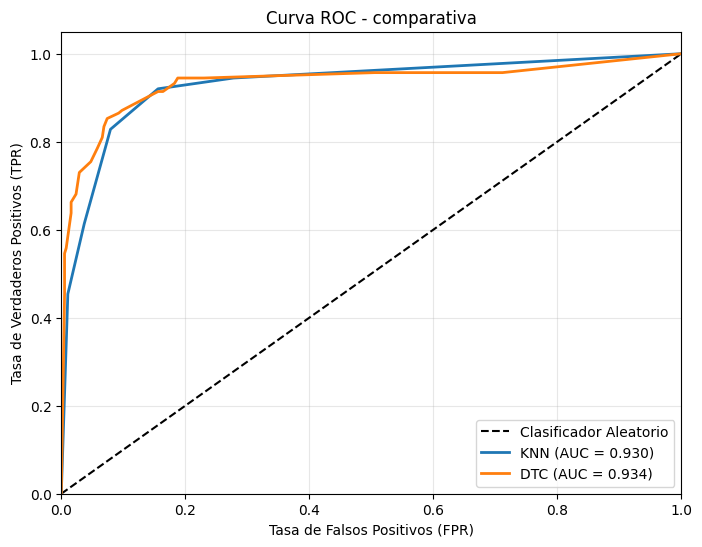

In [ ]:
#Curva de roc segun el tag

tags = ['KNN','DTC'] #Se puede modificar

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.title(f'Curva ROC - comparativa')


for tag in tags:
  model = models[tag]

  y_pred_prob = model.predict_proba(X_test)[:, 1]

  # Calcular curva ROC
  fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
  roc_auc = auc(fpr, tpr)

  # Graficar
  #plt.plot(fpr, tpr, color='#C74E51', lw=2,
  #        label=f'{tag} (AUC = {roc_auc:.3f})')
  plt.plot(fpr, tpr, lw=2,
          label=f'{tag} (AUC = {roc_auc:.3f})')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('Tasa de Falsos Positivos (FPR)')
  plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
  plt.legend(loc="lower right")
  plt.grid(True, alpha=0.3)
plt.show()

# K Vecinos Cercanos: Implementación manual vs. scikit-learn
 Estandarización y normalización de datos

In [ ]:
# Matriz de características X y variable objetivo y
X_knn = df_limpio.drop(columns=['clase_pos', 'position']) #features
y_knn = df_limpio['clase_pos'] #target

num_cols = X_knn.select_dtypes(include=np.number).columns.tolist()
# Include 'category' dtype to ensure columns like 'clase' are captured
cat_cols = X_knn.select_dtypes(include=['object', 'category']).columns.tolist()

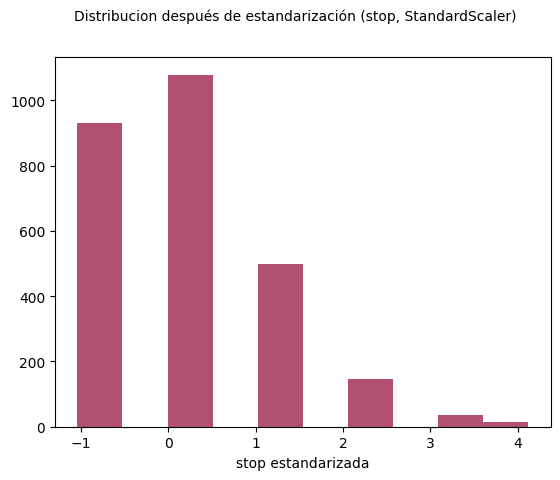

In [ ]:
# Estandarizar (media = 0, desviación estándar = 1)
X_num = X_knn[num_cols]
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_num)

## Histograma de las variables estandarizadas (Ejemplo)

plt.hist(X_std[:, num_cols.index('stop')], bins=10, color='#B25074')
plt.suptitle("Distribucion después de estandarización (stop, StandardScaler)", fontsize=10)
plt.xlabel('stop estandarizada')
plt.show()

## Predicción de Clases en F1

Este proyecto se enfoca en predecir el rendimiento de los pilotos de Fórmula 1, específicamente si terminarán en el podio (posición del 1 al 3) o dentro de los puntos (posición del 4 al 10), utilizando un modelo de **K Vecinos Más Cercanos (KNN)**.

### Fases del Proyecto:
1.  **Carga y Preprocesamiento de Datos:** Se combinaron datos de pit stops, pilotos y clasificaciones de la Fórmula 1 (`pit_stops.csv`, `drivers.csv`, `driver_standings.csv`). Se realizó una limpieza exhaustiva, incluyendo la eliminación de columnas redundantes, limitar las posiciones hasta la decima en cada carrera, y la creación de una variable objetivo `clase_pos` que indica si un piloto terminó en el podio (1) o en los puntos (0).
2.  **Preparación de Características:** Se identificaron las variables numéricas (`raceId`, `driverId`, `stop`, `seconds`) para ser usadas como características (`X`), y la `clase` como variable objetivo (`y`).
3.  **Escalado de Datos:** Las variables numéricas fueron estandarizadas (media 0, desviación estándar 1) y normalizadas (Min-Max) para asegurar que todas contribuyan equitativamente al cálculo de distancias del algoritmo KNN. Se utilizó `StandardScaler` para las predicciones.
4.  **Implementación y Comparación de KNN:** Se implementó una versión manual del algoritmo KNN con distancia euclidiana y se comparó con la implementación `KNeighborsClassifier` de `scikit-learn`. Se dividió el conjunto de datos en entrenamiento y prueba, y se realizaron predicciones con ambas versiones.



In [ ]:
scaler_knn = StandardScaler()
encoder_knn = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler_knn, num_cols),
        ('cat', encoder_knn, cat_cols)
    ]
    ,remainder='drop'
)

#aplicacion

X_processed_knn = preprocessor.fit_transform(X_knn)
print(X_processed_knn)

[[-1.71599891 -1.18549032 -0.00648803 ...  0.          0.
   0.        ]
 [-1.71599891 -1.17805196  1.02472758 ...  0.          0.
   0.        ]
 [-1.71599891 -1.15573689  1.02472758 ...  0.          0.
   0.        ]
 ...
 [ 1.697827    0.9096471  -1.03770365 ...  0.          0.
   0.        ]
 [ 1.697827    0.91212655 -1.03770365 ...  0.          0.
   0.        ]
 [ 1.697827    0.93692107 -0.00648803 ...  0.          0.
   0.        ]]


In [ ]:
def knn_dist_euclidea(data_x, data_y, x_new, k):
    """
    Implementación manual de KNN con distancia euclidiana.

    Parámetros:
        data_x: DataFrame con las variables predictoras (ya escaladas)
        data_y: Serie con las clases correspondientes
        x_new:  Array con las características del nuevo punto (también escalado)
        k:      Número de vecinos a considerar

    Return:
        knn: lista con los k vecinos más cercanos [(distancia, índice), ...]
        prediction: clase predicha por mayoría
    """
    import numpy as np
    from scipy.stats import mode

    distances = []
    for i in range(len(data_x)):
        row = data_x.iloc[i].to_numpy()
        diff = x_new - row
        dist = np.sqrt(np.sum(diff ** 2))
        distances.append((dist, i))

    distances = sorted(distances, key=lambda a: a[0])
    knn = distances[:k]

    categories = [data_y.iloc[i] for _, i in knn]
    categories = np.array(categories)

    prediction = mode(categories, keepdims=True).mode[0]

    return knn, prediction

In [ ]:
k = 5

# 1. Dividir el conjunto en entrenamiento y validación
X_train_knn_array, X_test_knn_array, y_train_knn, y_test_knn = train_test_split(X_processed_knn, y_knn, test_size=0.2, random_state=42)

# Convert NumPy arrays to pandas DataFrames as expected by knn_dist_euclidea
X_train_knn_df = pd.DataFrame(X_train_knn_array)
X_test_knn_df = pd.DataFrame(X_test_knn_array)

# 2. Predicciones manuales sobre todo el conjunto de validación
y_pred_manual = []

for i in range(len(X_test_knn_df)):
    x_new = X_test_knn_df.iloc[i].to_numpy()  # This will now work
    _, pred = knn_dist_euclidea(X_train_knn_df, y_train_knn, x_new, k)
    y_pred_manual.append(pred)

# 3. Predicciones con scikit-learn
knn_sklearn = KNeighborsCl≠assifier(n_neighbors=5) # instanciamos
knn_sklearn.fit(X_train_knn_array, y_train_knn) # entrenamos, scikit-learn expects arrays
y_pred_sklearn = knn_sklearn.predict(X_test_knn_array) # predecimos, scikit-learn expects arrays

# 4. Comparación
accuracy_manual = accuracy_score(y_test_knn, y_pred_manual)
accuracy_sklearn = accuracy_score(y_test_knn, y_pred_sklearn)

print("Comparación de predicciones sobre conjunto de validación:")
print(f"Exactitud (manual):       {accuracy_manual:.4f}")
print(f"Exactitud (scikit-learn): {accuracy_sklearn:.4f}")

Comparación de predicciones sobre conjunto de validación:
Exactitud (manual):       0.8928
Exactitud (scikit-learn): 0.8928


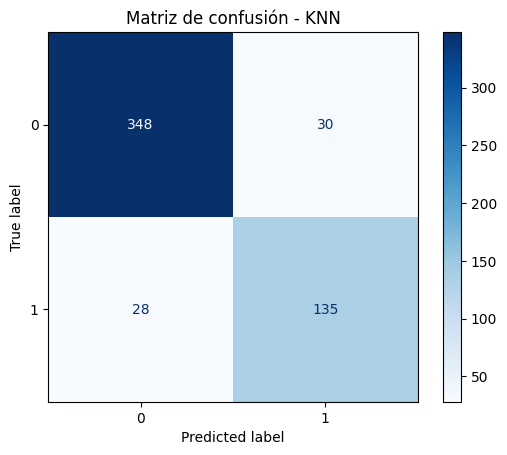

In [ ]:
cm_knn = confusion_matrix(y_test_knn, y_pred_sklearn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)

# Dibujamos el gráfico
disp.plot(cmap='Blues')
plt.title('Matriz de confusión - KNN')
plt.show()

### Resultados Preliminares:
La comparación inicial mostró que tanto la implementación manual como la de `scikit-learn` lograron una **exactitud similar (aproximadamente 0.89)** en el conjunto de validación, confirmando que la lógica manual replica correctamente el comportamiento del modelo estándar. Ahora, profundizaremos en los resultados de la clasificación con matrices de confusión y reportes de clasificación.

###Conclusiones con KNN
La comparación entre nuestra implementación manual del algoritmo de K Vecinos Más Cercanos (KNN) y la versión provista por scikit-learn muestra que ambas alcanzan resultados equivalentes en términos de exactitud sobre el conjunto de validación (≈ 65.62%). Esto confirma que se ha replicado correctamente la lógica central del modelo: cálculo de distancias euclidianas, selección de vecinos más cercanos y votación por mayoría.

Sin embargo, también se evidenció una diferencia importante en eficiencia computacional. La versión manual resulta mucho más lenta al predecir múltiples observaciones, ya que calcula las distancias de manera secuencial recorriendo todos los puntos de entrenamiento. En contraste, la implementación de scikit-learn aprovecha estructuras optimizadas como KD-Trees, Ball Trees y operaciones vectorizadas con NumPy, reduciendo significativamente el tiempo de cómputo.


### Análisis matemático

Cada observación del dataset se representa como un vector de características:

$$
X = [x_1, x_2, x_3, \ldots, x_n]
$$

donde cada componente corresponde a una variable del proyecto, como:

*   Número de pit stops
*   Tiempo acumulado en pits
*   Información del piloto

Variable objetivo:
$$
y \in \{0,1\}
$$
Donde:
| clase | significado |
| ----- | ----------- |
| 1     | podio       |
| 0     | no podio    |



Debido a que KNN depende directamente de distancias, fue necesario transformar las variables numéricas para evitar que variables con escalas grandes dominaran el cálculo matemático. Cada variable numérica es transformada para que todas tengan una media de 0 y una desviación estándar de 1. Usamos la siguiente fórmula:

z=x−μσ

x= stop original
μ= media
σ= desviación estándar
Para la variable stop, el proyecto obtuvo valores estandarizados como:

z≈−1.71599891

y
z≈1.697827

los cuales corresponden a observaciones por debajo y por encima de la media respectivamente.

La matriz transformada obtenida fue:

$$
[[−1.71599891−1.18549032−0.00648803...]...[1.6978270.93692107−0.00648803...]]
$$

Matemáticamente, esta transformación garantiza una media de 0 y una desviación estándar de 1 para todas las variables numéricas.







El núcleo matemático de KNN es el cálculo de distancias entre observaciones.En el proyecto se implemento manualmente con:


diff = x_new - row


dist = np.sqrt(np.sum(diff ** 2)).

La distancia utilizada fue la distancia euclidiana:
$$
d(x,y)=\sqrt\sum_{i=1}^{n}(x_i-y_i)^2
$$



*   $x_i=$ característica del nuevo dato
*   $y_i=$ característica de una oberrvación del entrenamiento
*   $n=$ número total de variables



El procedimiento matemático realizado por el algoritmo fue:


1.   Restar características

$$
(x_i-y_i)
$$

2.   Elevar al cuadrado

$$
(x_i-y_i)^2
$$

3.   Sumar todas las diferencias

$$
\sum_{i=1}^{n}(x_i-y_i)^2
$$

4. Obtener la raíz cuadrada

$$
\sqrt\sum_{i=1}^{n}(x_i-y_i)^2
$$

El resultado representa la proximidad entre observaciones del dataset.

EN la selección de vecinos usamos $k=5$. Por lo que el algoritmo ordenó todas las distancias calculadas:

$$
d_{(1)} \le d_{(2)} \le d_{(3)} \le \dots \le d_{(n)}
$$

y seleccionoó las 5 mejores con knn = distances[:k]

Matemáticamnte está escrito así:

$$
\{d_{(1)},d_{(2)},d_{(3)},d_{(4)},d_{(5)}\}
$$



Después clasificamos por mayoría. Cada vecino posee una clase $y_i \in \{0,1\}$.
La predicción se obtuvo sacando la moda con prediction = mode(categories, keepdims=True).mode[0]

Matematicamente:

$$
\hat{y}=\operatorname{mode}(y_1,y_2,\dots,y_k)
$$

donde $\hat{y}$ representa la clase predicha

El conjunto de datos fue dividido mediante: train_test_split(X_processed_knn, y_knn, test_size=0.2, random_state=42),

Se utilizo 80% de entrenamiento y 20% de validación. El conjunto de entrenamiento fue utilizado para calcular vecinos y el conjunto de prueba para evaluar desempeño.

El algoritmo manual recorrio todas las observaciones del entrenamiento con for i in range(len(data_x)):.

Se calculo la distancia de cada observación $d_1,d_2,d_3,\dots,d_n$
y después fueron ordenadas y finalmente se aplico la votación por mayoría.

El desempeño del modelo fue evaluado con:



*   Accruracy_score
*   Precision_score
*   Recall_Score
*   F1_score

**Accuracy**

Se define como:

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

y el resultado obtendio fue de 89.28%, lo que indica quelas observaciones fueron clasificadas correctamente.

**Precision**

$$
Precision=\frac{TP}{TP+FP}=0.8932
$$

**Recall**

$$
Recall=\frac{TP}{TP+FN}=0.8928
$$

**F1 score**

$$
F1=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}
$$

Sustituimos:

$$
F1=2\cdot\frac{(0.8932)(0.8928)}{0.8932+0.8928}=0.8930
$$



Se generó la matriz de confusión:

|               | Predijo podio | Predijo no podio |
| ------------- | ------------- | ---------------- |
| Real podio    | TP            | FN               |
| Real no podio | FP            | TN               |

Esta matriz permitió analizar:

*   Verdaderos positivos
*   Verdaderos negativos
*   Falsos positivos
*   Falsos negativos



El proyecto desarrollo dos versiones del algoritmo:


| implementación | descripción                              |
| -------------- | ---------------------------------------- |
| manual         | desarrollada desde cero                  |
| scikit-learn   | implementación optimizada de la librería |



Los resultados obtenidos manualmente y por medio de sklearn en accuracy fueron los mismos (0.8928). Esto demuestra que el cálculo de distancias, la selección de vecinos y la votación por mayoría fueron implementados correctamente.


#Árboles de decisión: implementación

División de conjunto de entrenamiento y validacion

In [ ]:
X_tree = df_limpio.drop(columns=['clase_pos', 'position']) #quitamos 'objetos'
y_tree = df_limpio['clase_pos'] #target

num_cols = X_tree.select_dtypes(include=np.number).columns.tolist()
# Include 'category' dtype to ensure columns like 'clase' are captured
cat_cols = X_tree.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
scaler_tree = StandardScaler()
encoder_tree = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler_tree, num_cols),
        ('cat', encoder_tree, cat_cols)
    ]
    ,remainder='drop'
)

#aplicacion

X_processed_tree = preprocessor.fit_transform(X_tree)
print(X_processed_tree)

[[-1.71599891 -1.18549032 -0.00648803 ...  0.          0.
   0.        ]
 [-1.71599891 -1.17805196  1.02472758 ...  0.          0.
   0.        ]
 [-1.71599891 -1.15573689  1.02472758 ...  0.          0.
   0.        ]
 ...
 [ 1.697827    0.9096471  -1.03770365 ...  0.          0.
   0.        ]
 [ 1.697827    0.91212655 -1.03770365 ...  0.          0.
   0.        ]
 [ 1.697827    0.93692107 -0.00648803 ...  0.          0.
   0.        ]]


In [ ]:
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_processed_tree,
                                                    y_tree,
                                                    test_size=0.2,
                                                    random_state=42)

In [ ]:
# 1. Instanciamos el modelo y sus hiperparámetros
tree = DecisionTreeClassifier(max_depth=10,
                              min_samples_split=30,# numero minimo de elementos para llevar a cabo una division (default 2)
                              random_state=42,
                              min_samples_leaf=7) # numero de elementos para ser considerado (default 1)

# 2. Entrenamos con el conjunto de entrenamiento
tree.fit(X_train_tree, y_train_tree)

# 3. Predicciones de clases y evaluación básica
y_pred = tree.predict(X_test_tree)

accuracy = accuracy_score(y_test_tree, y_pred)

# 4. Predicciones con probabilidades predichas
# Probabilidades para ROC y AUC
y_prob = tree.predict_proba(X_test_tree) # Aquí hacemos una modificación, incluimos las probabilidades de todas las clases

# Matriz de confusión
cm = confusion_matrix(y_test_tree, y_pred)

# Reportes detallados (incluye precisión, recall y F1)
print("=== Reporte modelo completo ===")
print(classification_report(y_test_tree, y_pred))

=== Reporte modelo completo ===
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       378
           1       0.85      0.79      0.82       163

    accuracy                           0.89       541
   macro avg       0.88      0.86      0.87       541
weighted avg       0.89      0.89      0.89       541

0.8946395563770795


In [ ]:
#implementación manual de dtc

class Node:
    """Representa un nodo en el árbol de decisión."""
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index  # Índice de la característica para la división
        self.threshold = threshold          # Valor umbral para la división
        self.left = left                    # Nodo hijo izquierdo
        self.right = right                  # Nodo hijo derecho
        self.value = value                  # Valor de la clase si es un nodo hoja

def gini_impurity(y):
    """Calcula la impureza Gini para un conjunto de etiquetas."""
    classes = np.unique(y)
    gini = 0.0
    for cls in classes:
        p = np.sum(y == cls) / len(y)
        gini += p * p
    return 1.0 - gini

def find_best_split(X, y):
    """Encuentra la mejor característica y umbral para dividir los datos."""
    n_samples, n_features = X.shape
    if n_samples <= 1: # No se puede dividir con 1 o menos muestras
        return None, None

    best_gini = 1.0
    best_feature_idx = None
    best_threshold = None

    for feature_idx in range(n_features):
        # Para cada característica, probamos cada valor único como un posible umbral de división.
        # Esto puede ser lento para muchos valores únicos.
        thresholds = np.unique(X[:, feature_idx])

        for threshold in thresholds:
            left_mask = X[:, feature_idx] <= threshold
            right_mask = X[:, feature_idx] > threshold

            y_left = y[left_mask]
            y_right = y[right_mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue # No es una división válida si un lado está vacío

            gini_left = gini_impurity(y_left)
            gini_right = gini_impurity(y_right)

            # Impureza Gini ponderada de la división
            weighted_gini = (len(y_left) / n_samples) * gini_left + \
                            (len(y_right) / n_samples) * gini_right

            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature_idx = feature_idx
                best_threshold = threshold

    return best_feature_idx, best_threshold

class DecisionTree_Manual:
    """Implementación manual de un Clasificador de Árbol de Decisión."""
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Condición de parada: máxima profundidad alcanzada, pocas muestras, o todas las muestras pertenecen a la misma clase
        if (self.max_depth is not None and depth >= self.max_depth) or \
           (n_samples < self.min_samples_split) or (n_labels == 1):
            # Si se cumple alguna condición, este es un nodo hoja
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Encontrar la mejor división para este nodo
        feature_idx, threshold = find_best_split(X, y)

        if feature_idx is None: # Si no se encontró una buena división (por ejemplo, impureza no mejoró)
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Dividir los datos basándose en la mejor división encontrada
        left_mask = X[:, feature_idx] <= threshold
        right_mask = X[:, feature_idx] > threshold

        X_left, y_left = X[left_mask], y[left_mask]
        X_right, y_right = X[right_mask], y[right_mask]

        # Construir recursivamente los nodos hijos
        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        # Devolver el nodo de decisión con sus hijos
        return Node(feature_index=feature_idx, threshold=threshold, left=left_child, right=right_child)

    def _most_common_label(self, y):
        """Encuentra la etiqueta de clase más común en un conjunto de etiquetas."""
        labels, counts = np.unique(y, return_counts=True)
        return labels[np.argmax(counts)]

    def fit(self, X, y):
        """Entrena el árbol de decisión con los datos de entrada."""
        self.tree = self._build_tree(X, y, depth=0)

    def _predict_single(self, x, node):
        """Realiza una predicción para una sola muestra."""
        if node.value is not None: # Si es un nodo hoja, devuelve su valor de clase
            return node.value

        # Si no es un nodo hoja, decide si va a la izquierda o a la derecha
        if x[node.feature_index] <= node.threshold:
            return self._predict_single(x, node.left)
        else:
            return self._predict_single(x, node.right)

    def predict(self, X):
        """Realiza predicciones para un conjunto de muestras."""
        return np.array([self._predict_single(x, self.tree) for x in X])

In [ ]:
X_train_np = X_train_tree
X_test_np = X_test_tree

# Crear y entrenar el DTC manual
# Usamos una profundidad máxima y un min_samples_split para una ejecución razonable y comparabilidad.
# Estos parámetros son similares a los utilizados en el DTC de scikit-learn.
manual_dtc = DecisionTree_Manual(max_depth=10, min_samples_split=30)
print("Entrenando DTC manual...")
# Convertir y_train a array de numpy, ya que la implementación manual no usa Series de pandas
manual_dtc.fit(X_train_np, y_train_tree.values)
print("DTC manual entrenado.")

# Realizar predicciones
y_pred_manual_train = manual_dtc.predict(X_train_np)
y_pred_manual_test = manual_dtc.predict(X_test_np)

# Calcular la precisión
accuracy_manual_train = accuracy_score(y_train_tree, y_pred_manual_train)
accuracy_manual_test = accuracy_score(y_test_tree, y_pred_manual_test)

print(f"\nAccuracy (Train - Manual DTC): {accuracy_manual_train:.4f}")
print(f"Accuracy (Test - Manual DTC): {accuracy_manual_test:.4f}")

# Recuperar la precisión del DTC de scikit-learn para comparación
sklearn_dtc_model = models['DTC'] # 'DTC' es la clave para el DecisionTreeClassifier de scikit-learn
y_pred_sklearn_train = sklearn_dtc_model.predict(X_train_np) # Usar X_train_np para consistencia
y_pred_sklearn_test = sklearn_dtc_model.predict(X_test_np) # Usar X_test_np para consistencia

accuracy_sklearn_train = accuracy_score(y_train_tree, y_pred_sklearn_train)
accuracy_sklearn_test = accuracy_score(y_test_tree, y_pred_sklearn_test)

print(f"\nAccuracy (Train - scikit-learn DTC): {accuracy_sklearn_train:.4f}")
print(f"Accuracy (Test - scikit-learn DTC): {accuracy_sklearn_test:.4f}")

Entrenando DTC manual...
DTC manual entrenado.

Accuracy (Train - Manual DTC): 0.9283
Accuracy (Test - Manual DTC): 0.8983

Accuracy (Train - scikit-learn DTC): 0.9255
Accuracy (Test - scikit-learn DTC): 0.8946


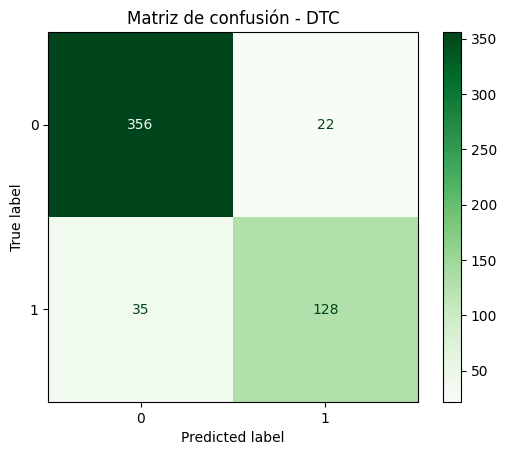

In [ ]:
# Visualización de matriz de confusión

# Creamos el gráfico a partir de la matriz ya calculada
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=tree.classes_)

# Dibujamos el gráfico
disp.plot(cmap='Greens')
plt.title('Matriz de confusión - DTC')
plt.show()

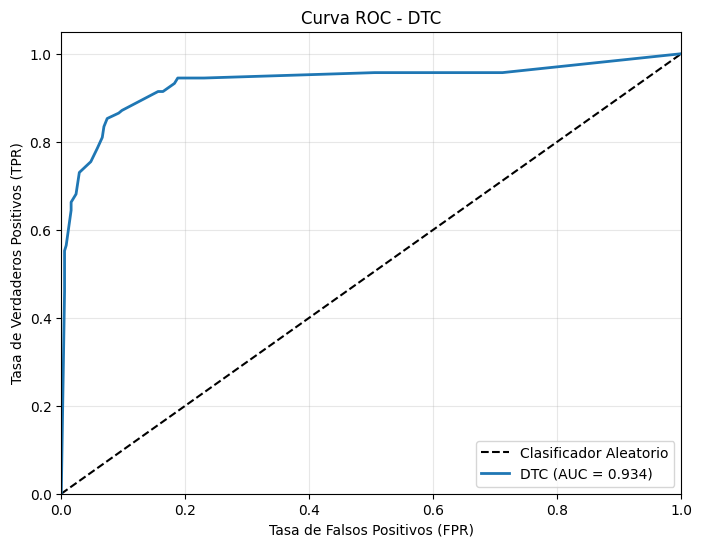

In [ ]:
from sklearn.metrics import auc

model_tree = tree

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.title(f'Curva ROC - DTC')


y_pred_prob = model_tree.predict_proba(X_test_tree)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test_tree, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Graficar
#plt.plot(fpr, tpr, color='#C74E51', lw=2,
#        label=f'{tag} (AUC = {roc_auc:.3f})')
plt.plot(fpr, tpr, lw=2,
        label=f'DTC (AUC = {roc_auc:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
feature_names_out = preprocessor.get_feature_names_out()
with open("df_limpio_dtree.dot", 'w') as dotfile:
    export_graphviz(tree, out_file=dotfile, feature_names=feature_names_out)
    dotfile.close()

In [ ]:
file = open("df_limpio_dtree.dot", "r")
text = file.read()

In [ ]:
# Se imprime el texto que contiene el archivo .dot que acabamos de generar
text

'digraph Tree {\nnode [shape=box, fontname="helvetica"] ;\nedge [fontname="helvetica"] ;\n0 [label="num__driverId <= -1.179\\ngini = 0.427\\nsamples = 2161\\nvalue = [1492, 669]"] ;\n1 [label="num__raceId <= -1.051\\ngini = 0.475\\nsamples = 307\\nvalue = [119.0, 188.0]"] ;\n0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="True"] ;\n2 [label="cat__driverRef_hamilton <= 0.5\\ngini = 0.32\\nsamples = 85\\nvalue = [68, 17]"] ;\n1 -> 2 ;\n3 [label="gini = 0.0\\nsamples = 42\\nvalue = [42, 0]"] ;\n2 -> 3 ;\n4 [label="num__raceId <= -1.417\\ngini = 0.478\\nsamples = 43\\nvalue = [26, 17]"] ;\n2 -> 4 ;\n5 [label="gini = 0.486\\nsamples = 24\\nvalue = [10, 14]"] ;\n4 -> 5 ;\n6 [label="gini = 0.266\\nsamples = 19\\nvalue = [16, 3]"] ;\n4 -> 6 ;\n7 [label="num__raceId <= 0.915\\ngini = 0.354\\nsamples = 222\\nvalue = [51, 171]"] ;\n1 -> 7 ;\n8 [label="num__raceId <= 0.419\\ngini = 0.012\\nsamples = 166\\nvalue = [1, 165]"] ;\n7 -> 8 ;\n9 [label="gini = 0.0\\nsamples = 139\\nvalue = [0, 139]"

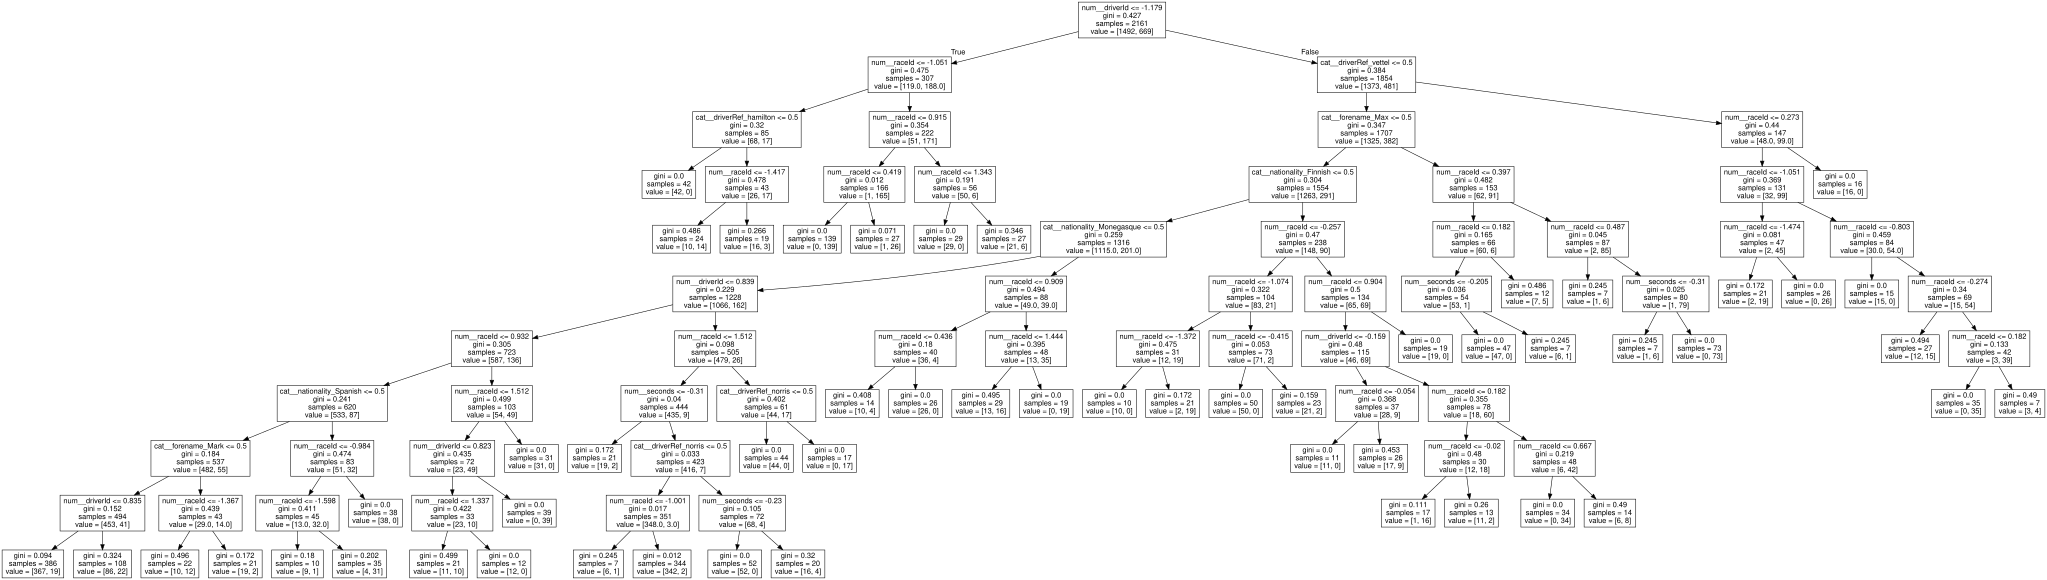

In [ ]:
Source(text)

### Análisis Matemático del Clasificador de Árbol de Decisión (DTC)

#### 1. Formulación Matemática del Modelo

Un Árbol de Decisión es un modelo no paramétrico que particiona el espacio de características en regiones rectangulares y asigna una etiqueta de clase (o un valor continuo para regresión) a cada región. Matemáticamente, el proceso de decisión se puede representar como un conjunto de reglas condicionales anidadas.

Para una instancia de entrada $x = (x_1, x_2, \dots, x_d)$, donde $x_j$ es el valor de la característica $j$, el árbol aplica una serie de pruebas binarias en los nodos internos. Cada nodo interno $m$ está asociado a una característica $j_m$ y un umbral $t_m$. La prueba es típicamente de la forma $x_{j_m} \le t_m$ (o $x_{j_m} > t_m$), dirigiendo la instancia a un subárbol izquierdo o derecho. Este proceso continúa hasta que se alcanza un nodo hoja. Un nodo hoja $l$ representa una región del espacio de características $R_l$ y se le asigna una etiqueta de clase $C_l$.

La función de predicción $f(x)$ para un DTC se puede expresar como:

$f(x) = \sum_{l=1}^{L} C_l \cdot \mathbb{I}(x \in R_l)$

Donde:
*   $L$ es el número total de nodos hoja en el árbol.
*   $C_l$ es la clase predicha para las instancias que caen en la región $R_l$ del nodo hoja $l$. Para clasificación, $C_l$ es la clase mayoritaria de las muestras de entrenamiento en esa hoja.
*   $\mathbb{I}(x \in R_l)$ es la función indicatriz, que es 1 si la instancia $x$ pertenece a la región $R_l$ y 0 en caso contrario.

**Variables:**
*   $x$: Vector de características de entrada.
*   $y$: Etiqueta de clase objetivo.

**Parámetros:**
*   Para cada nodo de división: `feature_index` (índice de la característica a dividir) y `threshold` (valor umbral para la división).
*   Para cada nodo hoja: `class_label` (la clase mayoritaria de las muestras en esa hoja).

**Supuestos Matemáticos:**
*   Las características son independientes o las dependencias pueden ser capturadas por divisiones sucesivas.
*   El modelo es capaz de particionar el espacio de entrada en regiones rectangulares.

#### 2. Función de Costo (Criterio de Impureza)

En la construcción de un DTC, la "función de costo" no es una función de costo global para optimizar directamente con un algoritmo iterativo como el descenso de gradiente. En su lugar, el árbol se construye de forma greedy, seleccionando en cada nodo la división que **minimiza la impureza** de los nodos hijos resultantes (o maximiza la ganancia de información).

Los criterios de impureza comunes para la clasificación son:

*   **Impureza Gini:** Si un nodo contiene una muestra de datos $D$ y $p_k$ es la proporción de muestras que pertenecen a la clase $k$ en ese nodo, la impureza Gini se define como:
    
    $Gini(D) = 1 - \sum_{k=1}^{K} p_k^2$
    
    Una impureza Gini de 0 significa que todas las muestras en el nodo pertenecen a la misma clase (nodo puro).

*   **Entropía (Ganancia de Información):** La entropía mide la aleatoriedad de los datos. Para un nodo $D$ con $p_k$ la proporción de la clase $k$:
    
    $Entropia(D) = - \sum_{k=1}^{K} p_k \log_2(p_k)$
    
    La Ganancia de Información de una división se calcula como la reducción en la entropía:
    
    $Ganancia(D, A) = Entropia(D) - \sum_{v \in Valores(A)} \frac{|D_v|}{|D|} Entropia(D_v)$
    
    Donde $A$ es la característica sobre la que se divide, y $D_v$ son los subconjuntos de datos para cada valor de $A$.

En la implementación proporcionada, se utiliza la **Impureza Gini** como función de costo local para encontrar la mejor división.

#### 3. Método de Optimización (Construcción del Árbol)

El método de optimización para construir un DTC es un algoritmo **greedy recursivo**. No se utiliza un método de optimización global como el descenso de gradiente, sino que el árbol se construye de arriba hacia abajo (top-down) mediante un proceso de **partición binaria recursiva**.

**Explicación Conceptual:**

1.  **Inicio:** El árbol comienza con un único nodo raíz que contiene todas las muestras de entrenamiento.
2.  **Búsqueda de la Mejor División:** En cada nodo, el algoritmo examina todas las características de entrada y todos los posibles valores de umbral para cada característica. Para cada combinación característica-umbral, calcula la impureza Gini (o entropía) de los dos grupos resultantes si se hiciera una división. El objetivo es encontrar la división que **minimice la impureza promedio ponderada** de los nodos hijos o, equivalentemente, **maximice la ganancia de información**.
3.  **División del Nodo:** Una vez que se encuentra la "mejor" característica y umbral para dividir los datos, el nodo se divide en dos nodos hijos (izquierdo y derecho) basados en esa regla.
4.  **Recursión:** El proceso se repite recursivamente para cada nodo hijo, tratándolos como nuevos nodos raíz de subárboles, hasta que se cumple una **condición de parada**.
5.  **Nodos Hoja:** Cuando se cumple una condición de parada (por ejemplo, la profundidad máxima del árbol ha sido alcanzada, el número de muestras en el nodo es menor que un umbral, o todas las muestras en el nodo pertenecen a la misma clase), el nodo se convierte en un nodo hoja y se le asigna la clase mayoritaria de las muestras de entrenamiento que cayeron en ese nodo.

Este enfoque es codicioso porque en cada paso elige la mejor división local sin considerar si esa división conducirá al mejor árbol global. Funciona porque busca reducir la incertidumbre (impureza) en los datos a cada paso, acercándose progresivamente a una clasificación más precisa.

#### 4. Propiedades Matemáticas Relevantes

*   **Existencia de una Solución Óptima:** En un sentido estricto, la construcción greedy de un DTC no garantiza encontrar el árbol óptimo global (el que minimiza la función de costo global). Encontrar el árbol óptimo es un problema NP-hard. Sin embargo, los algoritmos greedy encuentran un **óptimo local** en cada paso de división.
*   **Naturaleza Determinista:** Un DTC es un modelo determinista. Dada la misma entrada, siempre producirá la misma predicción. No tiene una naturaleza probabilística inherente en su construcción o predicción de clase (aunque algunas implementaciones pueden devolver probabilidades de clase basadas en las proporciones de las clases en el nodo hoja).
*   **Dimensionalidad de su Espacio:** La dimensionalidad de las características afecta directamente la complejidad computacional. Cuantas más características ($d$), más posibles divisiones hay que evaluar en cada nodo. El espacio de decisión es particionado en una colección de hiper-rectángulos, cada uno correspondiente a un nodo hoja.
*   **Necesidad de Supuestos:** Los DTC tienen pocos supuestos fuertes sobre la distribución de los datos o la relación entre las características y el objetivo, a diferencia de modelos lineales o probabilísticos (e.g., regresión lineal asume linealidad, Naive Bayes asume independencia de características). Esto los hace muy flexibles y aplicables a una amplia gama de problemas.
    *   **No linealidad:** Puede capturar relaciones no lineales complejas entre características y objetivo.
    *   **No requiere normalidad:** Las características no necesitan seguir una distribución normal.
    *   **No requiere escala:** No es sensible a la escala de las características (a menos que se usen umbrales sensibles a la escala, pero las divisiones se basan en valores absolutos).

#### 5. Pros y Contras del Modelo desde una Perspectiva Matemática

**Pros:**
*   **No Paramétrico y Flexible:** No asume una forma funcional para la relación entre las variables, lo que le permite modelar interacciones complejas y no lineales.
*   **Insensible a la Escala de Características:** Dado que las divisiones se basan en umbrales de valores de características individuales, el escalado de características no es necesario.
*   **Manejo de Datos Mixtos:** Puede manejar datos numéricos y categóricos de forma nativa (aunque la implementación común suele requerir codificación para categóricas).
*   **Interpretabilidad (para árboles pequeños):** La estructura del árbol es fácil de entender y visualizar, lo que permite una interpretación clara de las reglas de decisión.
*   **No Requiere Normalidad ni Supuestos de Linealidad:** Funciona bien con distribuciones de datos arbitrarias.
*   **No Tiene Solución en Forma Cerrada:** Su construcción es algorítmica y no se puede expresar con una fórmula simple.

**Contras:**
*   **Inestabilidad (Alta Varianza):** Pequeñas variaciones en los datos de entrenamiento pueden llevar a árboles completamente diferentes. Esto puede resultar en un sobreajuste.
*   **Sensibilidad a Outliers:** Los valores atípicos pueden influir en la elección de los umbrales de división, especialmente en características numéricas, afectando la estructura del árbol.
*   **Sobreajuste (Overfitting):** Sin técnicas de poda o restricciones de profundidad, los árboles pueden crecer muy profundos y ajustarse demasiado bien a los datos de entrenamiento, perdiendo capacidad de generalización.
*   **Bias hacia Características Dominantes:** Tiende a favorecer características con muchos niveles o valores, o aquellas que producen una gran reducción de impureza al principio, lo que puede no ser óptimo para la estructura general del árbol.
*   **Problema de Mínimos Locales:** Debido a su naturaleza greedy, el algoritmo solo encuentra un óptimo local en cada paso, no garantizando el árbol óptimo global.
*   **Costo Computacional (para árboles grandes):** En el peor de los casos, la búsqueda de la mejor división en cada nodo puede ser costosa, especialmente con muchas características y muestras, aunque las implementaciones optimizadas mitigan esto.

#### 6. Argumento Teórico sobre por qué el DTC es Adecuado para el Problema Elegido

Dado el problema general de clasificación (identificar una clase de salida discreta, en este caso, si un conductor está en el podio o en los puntos), el DTC es una opción adecuada por varias razones:

*   **Estructura Matemática y Tipo de Datos:** El DTC puede manejar una combinación de características numéricas (como segundos en pit stop) y categóricas (como `driverRef`, `nationality`), las cuales están presentes en el dataset `df_limpio`. Su capacidad para crear divisiones basadas en umbrales en características numéricas y categorías en características categóricas lo hace versátil.
*   **No Linealidad y Complejidad:** Las relaciones entre los tiempos de pit stop, la nacionalidad, el conductor y la posición final en la carrera probablemente no son lineales. Un DTC puede capturar estas interacciones complejas y no lineales, que modelos más simples (como la regresión logística) podrían pasar por alto.
*   **Interpretabilidad:** Aunque el problema no se define explícitamente como uno que requiera alta interpretabilidad, un DTC, especialmente si no es demasiado profundo, ofrece reglas de decisión que son fáciles de entender. Esto puede ser útil para comprender qué factores (por ejemplo, ciertos conductores, nacionalidades o rangos de tiempo de pit stop) contribuyen a una mejor posición.
*   **Pocos Supuestos:** El DTC no impone fuertes supuestos de distribución sobre los datos (como normalidad o linealidad), lo que lo hace robusto para datasets donde estas condiciones pueden no cumplirse.
*   **Naturaleza no Temporal:** El problema actual de clasificación de posiciones no parece tener una fuerte dependencia temporal directa (aunque la `raceId` tiene un orden, la clasificación de una carrera individual es independiente de la anterior para la *clase* de ese evento). El DTC no tiene una capacidad intrínseca para manejar secuencias temporales, lo que es apropiado aquí.
*   **Dimensionalidad Moderada:** Aunque el preprocesamiento con OneHotEncoder aumenta la dimensionalidad, los DTC pueden manejar un número moderado de características sin sufrir excesivamente de la maldición de la dimensionalidad como otros algoritmos (por ejemplo, KNN en su versión ingenua).

Conclusión, el DTC es una buena elección para este tipo de problema de clasificación debido a su flexibilidad para modelar relaciones complejas, su capacidad para trabajar con diversos tipos de datos y su interpretabilidad inherente, lo que lo convierte en una herramienta potente y comprensible para clasificar las posiciones en carreras.

Toledano, I. (2025) *MachineLearning_InferenciaBayesiana_CUGDL* [Repositorio de código]. GitHub. https://github.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL

eriklindernoren (2018) *ML-From-Scratch* [Repositorio de código]. Github. https://github.com/eriklindernoren/ML-From-Scratch/blob/master/mlfromscratch/supervised_learning/decision_tree.py